# PHẦN 4: TRÍCH XUẤT ĐẶC TRƯNG (FEATURE ENGINEERING)

Notebook này thực hiện toàn bộ quá trình trích xuất đặc trưng gồm:
1. Lựa chọn và loại bỏ đặc trưng dựa trên phân tích tương quan
2. Chuẩn hóa dữ liệu (StandardScaler)
3. Giảm chiều dữ liệu (PCA - Principal Component Analysis)
4. Trích xuất đặc trưng thời gian (Sin/Cos Encoding)
5. Tạo đặc trưng trễ (Lag Features)

## 0. Import thư viện và Load dữ liệu

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dữ liệu
train_df = pd.read_csv('clean_data/clean_data_train.csv')
test_df  = pd.read_csv('clean_data/clean_data_test.csv')

# Parse datetime
train_df['time'] = pd.to_datetime(train_df['time'])
test_df['time']  = pd.to_datetime(test_df['time'])

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"\nCác cột: {train_df.columns.tolist()}")

Train shape: (42573, 8)
Test shape:  (4731, 8)

Các cột: ['time', 'wind_speed_10m', 'temperature_2m', 'cloud_cover', 'relative_humidity_2m', 'surface_pressure', 'precipitation', 'vapour_pressure_deficit']


---
## 1. Lựa chọn và loại bỏ đặc trưng

Phân tích ma trận tương quan (Correlation Matrix) để đánh giá mức độ đóng góp thông tin của từng đặc trưng với biến mục tiêu `temperature_2m`, từ đó quyết định loại bỏ các biến gây ra hiện tượng rò rỉ dữ liệu (Data Leakage).

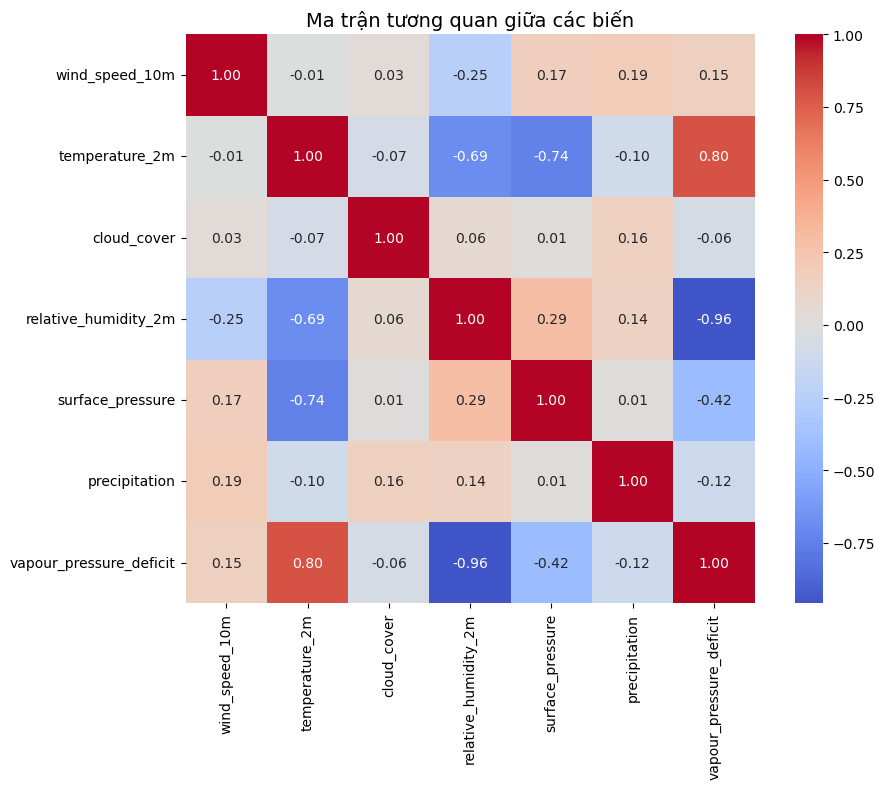


=== TƯƠNG QUAN VỚI temperature_2m ===
temperature_2m             1.000
vapour_pressure_deficit    0.796
wind_speed_10m            -0.009
cloud_cover               -0.070
precipitation             -0.095
relative_humidity_2m      -0.690
surface_pressure          -0.737
Name: temperature_2m, dtype: float64


In [39]:
# ==================================================
# 1.1 Phân tích ma trận tương quan
# ==================================================
numeric_cols = [col for col in train_df.columns if col != 'time']
corr_matrix = train_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax)
ax.set_title('Ma trận tương quan giữa các biến', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== TƯƠNG QUAN VỚI temperature_2m ===")
print(corr_matrix['temperature_2m'].sort_values(ascending=False).round(3))

---
## 2. Phân tích thành phần chính (PCA)

Theo tài liệu bài giảng Chương 7 - Phân tích dữ liệu nhiều chiều, PCA sử dụng phép biến đổi trực giao để chuyển dữ liệu từ không gian nhiều chiều sang không gian mới ít chiều hơn, nhằm tối ưu hóa việc thể hiện sự biến thiên của dữ liệu.

**Quy trình PCA gồm các bước:**
1. Chuẩn hóa dữ liệu (StandardScaler)
2. Tính ma trận hiệp phương sai
3. Phân tích giá trị riêng (Explained Variance)
4. Phân tích Loading Matrix
5. Lựa chọn số chiều K và Transform

### 2.1 Chuẩn hóa dữ liệu (StandardScaler)

Chuẩn hóa Z-score là bước bắt buộc trước PCA vì PCA dựa trên phương sai — nếu không chuẩn hóa, biến có đơn vị lớn (như `surface_pressure` ~1009 hPa) sẽ chi phối toàn bộ kết quả PCA.

In [40]:
# ==================================================
# 2.1 Chuẩn hóa dữ liệu (StandardScaler)
# Công thức: z = (x - mean) / std
# Chỉ fit trên train, transform cả train lẫn test
# ==================================================
feature_cols = ['wind_speed_10m', 'cloud_cover', 'relative_humidity_2m',
                'surface_pressure', 'precipitation', 'vapour_pressure_deficit']

X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform trên train
X_test_scaled  = scaler.transform(X_test)        # chỉ transform trên test

print("=== KẾT QUẢ CHUẨN HÓA ===")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print(f"\nTrước chuẩn hóa — Mean: {X_train.mean(axis=0).round(3)}")
print(f"Trước chuẩn hóa — Std:  {X_train.std(axis=0).round(3)}")
print(f"\nSau chuẩn hóa  — Mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Sau chuẩn hóa  — Std:  {X_train_scaled.std(axis=0).round(4)}")

=== KẾT QUẢ CHUẨN HÓA ===

X_train_scaled shape: (42573, 6)
X_test_scaled shape:  (4731, 6)

Trước chuẩn hóa — Mean: [1.032300e+01 7.468700e+01 8.187400e+01 1.009028e+03 2.760000e-01
 7.040000e-01]
Trước chuẩn hóa — Std:  [ 6.518 34.041 11.703  5.383  1.097  0.642]

Sau chuẩn hóa  — Mean: [-0. -0. -0. -0.  0.  0.]
Sau chuẩn hóa  — Std:  [1. 1. 1. 1. 1. 1.]


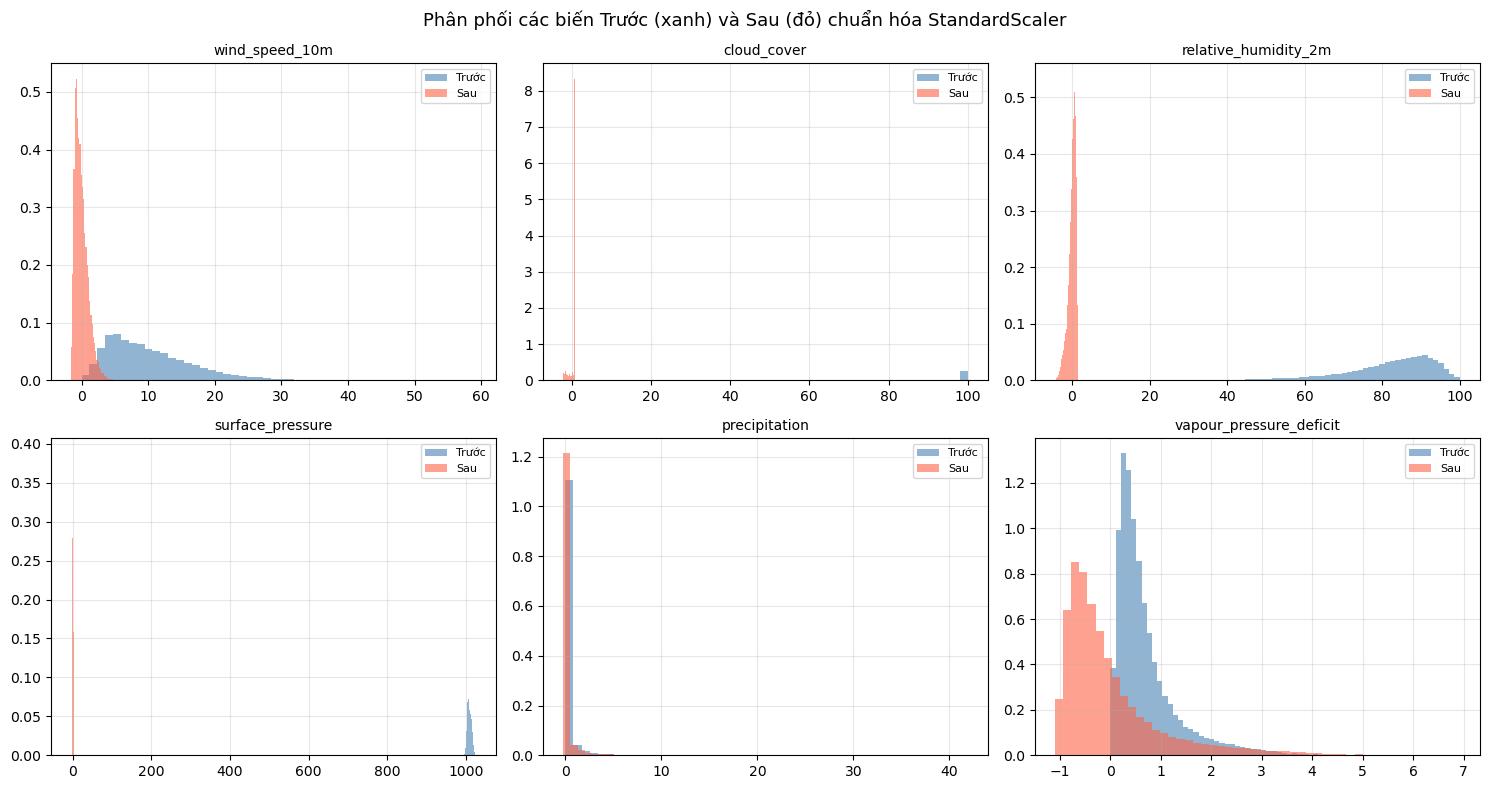

In [41]:
# ==================================================
# TRỰC QUAN HÓA: So sánh phân phối Trước và Sau chuẩn hóa
# ==================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(feature_cols):
    ax = axes[i//3][i%3]
    ax.hist(X_train[:, i], bins=50, alpha=0.6,
            color='steelblue', label='Trước', density=True)
    ax.hist(X_train_scaled[:, i], bins=50, alpha=0.6,
            color='tomato', label='Sau', density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Phân phối các biến Trước (xanh) và Sau (đỏ) chuẩn hóa StandardScaler',
             fontsize=13)
plt.tight_layout()
plt.show()

### 2.2 Tính ma trận hiệp phương sai

Ma trận hiệp phương sai S được tính theo công thức:
$$S = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)(x_i - \mu)^T$$

=== MA TRẬN HIỆP PHƯƠNG SAI ===
                         wind_speed_10m  cloud_cover  relative_humidity_2m  \
wind_speed_10m                    1.000        0.032                -0.248   
cloud_cover                       0.032        1.000                 0.060   
relative_humidity_2m             -0.248        0.060                 1.000   
surface_pressure                  0.170        0.007                 0.291   
precipitation                     0.193        0.158                 0.136   
vapour_pressure_deficit           0.155       -0.058                -0.958   

                         surface_pressure  precipitation  \
wind_speed_10m                      0.170          0.193   
cloud_cover                         0.007          0.158   
relative_humidity_2m                0.291          0.136   
surface_pressure                    1.000          0.012   
precipitation                       0.012          1.000   
vapour_pressure_deficit            -0.416         -0.122   



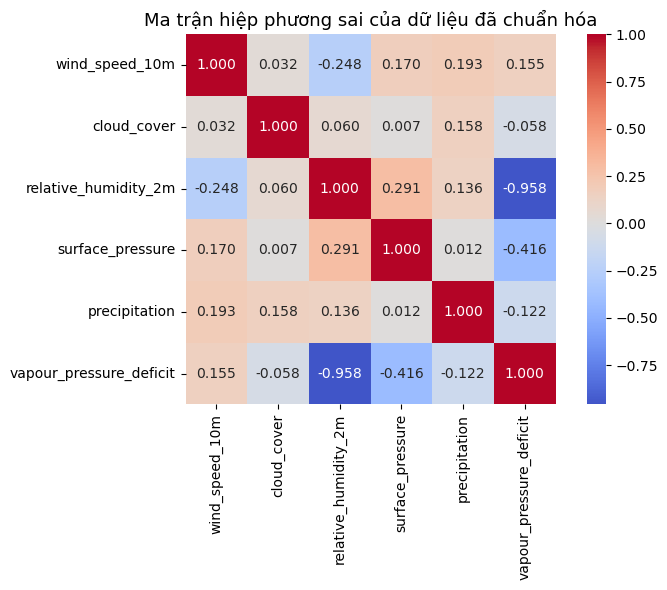

In [42]:
# ==================================================
# 2.2 Tính ma trận hiệp phương sai
# ==================================================
cov_matrix = np.cov(X_train_scaled.T)
cov_df = pd.DataFrame(cov_matrix, index=feature_cols, columns=feature_cols)

print("=== MA TRẬN HIỆP PHƯƠNG SAI ===")
print(cov_df.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cov_df,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax)
ax.set_title('Ma trận hiệp phương sai của dữ liệu đã chuẩn hóa', fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Phân tích giá trị riêng (Explained Variance)

Tỉ lệ thông tin được giữ lại khi chọn K thành phần chính được tính theo công thức:
$$r_K = \frac{\sum_{i=1}^{K} \lambda_i}{\sum_{j=1}^{D} \lambda_j}$$

=== PHÂN TÍCH GIÁ TRỊ RIÊNG ===

PC       Giá trị riêng  Explained Var (%)  Tích lũy (%)
-------------------------------------------------------
PC1             2.2287             37.14%        37.14%
PC2             1.2959             21.60%        58.74%
PC3             1.0695             17.82%        76.57%
PC4             0.8489             14.15%        90.71%
PC5             0.5271              8.78%        99.50%
PC6             0.0302              0.50%       100.00%


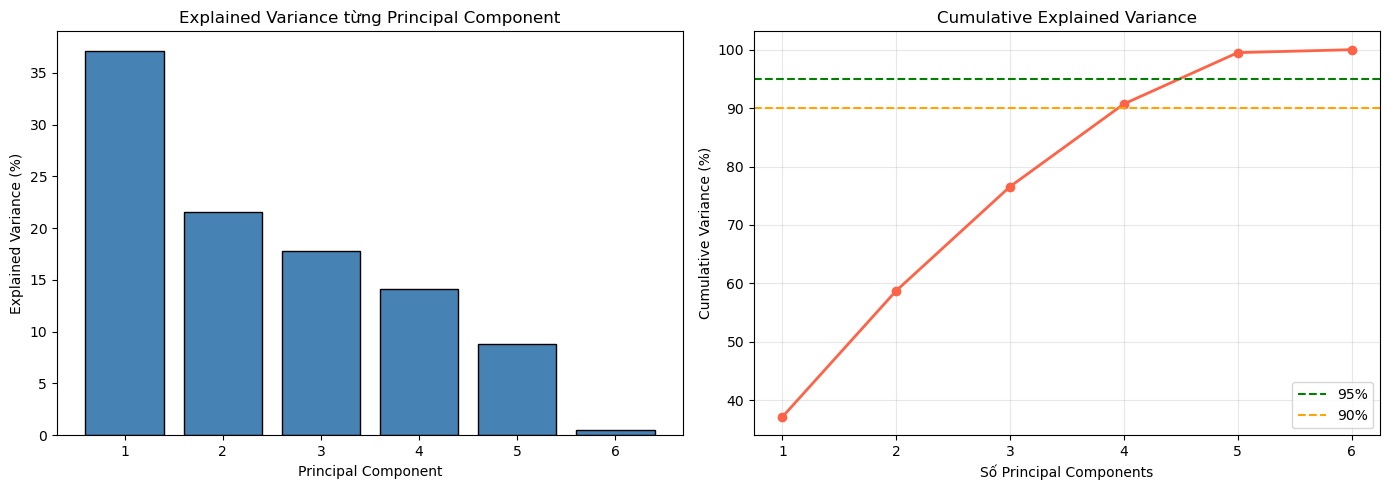

In [43]:
# ==================================================
# 2.3 Phân tích giá trị riêng (Explained Variance)
# ==================================================
pca_full = PCA()
pca_full.fit(X_train_scaled)

eigenvalues   = pca_full.explained_variance_
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("=== PHÂN TÍCH GIÁ TRỊ RIÊNG ===")
print(f"\n{'PC':<6} {'Giá trị riêng':>15} {'Explained Var (%)':>18} {'Tích lũy (%)':>13}")
print("-" * 55)
for i, (ev, exp, cum) in enumerate(zip(eigenvalues, explained_var, cumulative_var)):
    print(f"PC{i+1:<4} {ev:>15.4f} {exp*100:>17.2f}% {cum*100:>12.2f}%")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_var)+1), explained_var*100,
            color='steelblue', edgecolor='black')
axes[0].set_title('Explained Variance từng Principal Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_xticks(range(1, len(explained_var)+1))

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100,
             marker='o', color='tomato', linewidth=2)
axes[1].axhline(y=95, color='green', linestyle='--', label='95%')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90%')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Số Principal Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_xticks(range(1, len(cumulative_var)+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.4 Phân tích Loading Matrix

Loading Matrix thể hiện mức độ đóng góp (tải trọng) của từng biến gốc vào từng thành phần chính, giúp diễn giải ý nghĩa vật lý của từng PC.

=== LOADING MATRIX ===
                           PC1    PC2    PC3    PC4    PC5    PC6
wind_speed_10m           0.140  0.677 -0.405  0.003  0.597  0.052
cloud_cover             -0.076  0.359  0.623  0.690  0.030  0.001
relative_humidity_2m    -0.639 -0.109  0.095 -0.112  0.279  0.694
surface_pressure        -0.355  0.256 -0.561  0.361 -0.597  0.089
precipitation           -0.126  0.578  0.351 -0.616 -0.383 -0.019
vapour_pressure_deficit  0.652  0.040  0.016  0.047 -0.250  0.713


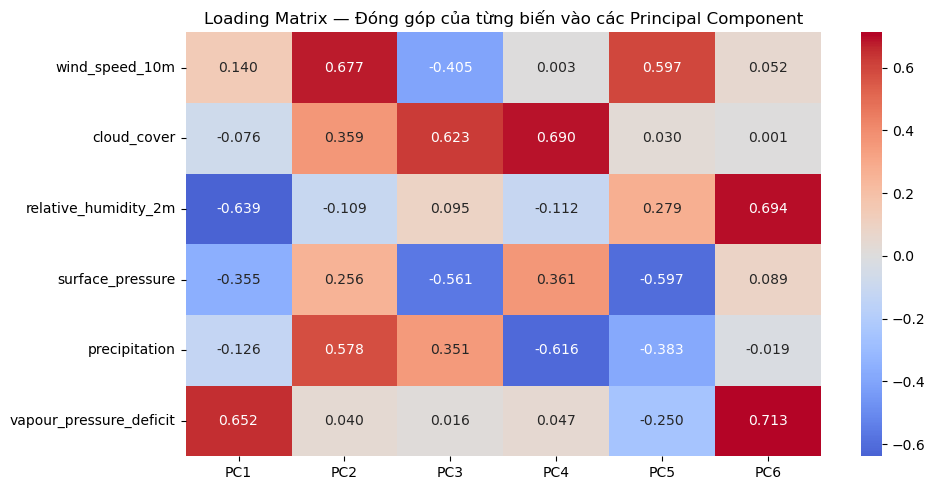


=== Ý NGHĨA TỪNG PC ===
PC1 (37.14%): chủ yếu bởi vapour_pressure_deficit (0.652) và relative_humidity_2m (-0.639)
PC2 (21.60%): chủ yếu bởi wind_speed_10m (0.677) và precipitation (0.578)
PC3 (17.82%): chủ yếu bởi cloud_cover (0.623) và surface_pressure (-0.561)
PC4 (14.15%): chủ yếu bởi cloud_cover (0.690) và precipitation (-0.616)
PC5 (8.78%): chủ yếu bởi wind_speed_10m (0.597) và surface_pressure (-0.597)


In [44]:
# ==================================================
# 2.4 Phân tích Loading Matrix
# ==================================================
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(feature_cols))],
    index=feature_cols
)

print("=== LOADING MATRIX ===")
print(loadings.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(loadings,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            ax=ax)
ax.set_title('Loading Matrix — Đóng góp của từng biến vào các Principal Component',
             fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== Ý NGHĨA TỪNG PC ===")
for i in range(5):
    pc = loadings[f'PC{i+1}']
    top = pc.abs().nlargest(2).index.tolist()
    print(f"PC{i+1} ({explained_var[i]*100:.2f}%): chủ yếu bởi {top[0]} ({pc[top[0]]:.3f}) và {top[1]} ({pc[top[1]]:.3f})")

### 2.5 Lựa chọn số chiều K = 5 và Transform dữ liệu

Dựa trên kết quả phân tích Explained Variance, nhóm chọn **K = 5** thành phần chính:
- PC1–PC5 giữ lại **99.50%** tổng phương sai
- PC6 chỉ đóng góp **0.50%** → loại bỏ không đáng kể về mặt thông tin

In [45]:
# ==================================================
# 2.5 Lựa chọn K = 5 và Transform dữ liệu
# w là vector riêng ứng với 5 giá trị riêng lớn nhất
# (theo tài liệu bài giảng Chương 7 - PCA)
# ==================================================
n_components = 5
pca_final = PCA(n_components=n_components)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

print(f"=== KẾT QUẢ PCA VỚI K = {n_components} ===")
print(f"Variance được giữ lại: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Số chiều ban đầu: {X_train_scaled.shape[1]}")
print(f"Số chiều sau PCA: {X_train_pca.shape[1]}")
print(f"\nX_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape:  {X_test_pca.shape}")

# Tạo DataFrame PCA
pca_cols = [f'PC{i+1}' for i in range(n_components)]

train_pca_df = pd.DataFrame(X_train_pca, columns=pca_cols)
train_pca_df.insert(0, 'time', train_df['time'].values)
train_pca_df['temperature_2m'] = train_df['temperature_2m'].values

test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols)
test_pca_df.insert(0, 'time', test_df['time'].values)
test_pca_df['temperature_2m'] = test_df['temperature_2m'].values

print("\nTrain PCA DataFrame (5 dòng đầu):")
print(train_pca_df.head())

=== KẾT QUẢ PCA VỚI K = 5 ===
Variance được giữ lại: 99.50%
Số chiều ban đầu: 6
Số chiều sau PCA: 5

X_train_pca shape: (42573, 5)
X_test_pca shape:  (4731, 5)

Train PCA DataFrame (5 dòng đầu):
                 time       PC1       PC2       PC3       PC4       PC5  \
0 2021-01-01 00:00:00  0.121324  2.398272 -1.870897  1.529343  0.077376   
1 2021-01-01 01:00:00  0.270790  2.193988 -1.713070  1.518056 -0.112719   
2 2021-01-01 02:00:00  0.421603  2.101757 -1.631623  1.467929 -0.142518   
3 2021-01-01 03:00:00  0.413063  2.049006 -1.758613  1.262522 -0.006384   
4 2021-01-01 04:00:00  0.469278  2.135854 -1.613039  1.479711 -0.107621   

   temperature_2m  
0           19.50  
1           19.50  
2           19.35  
3           19.20  
4           19.25  


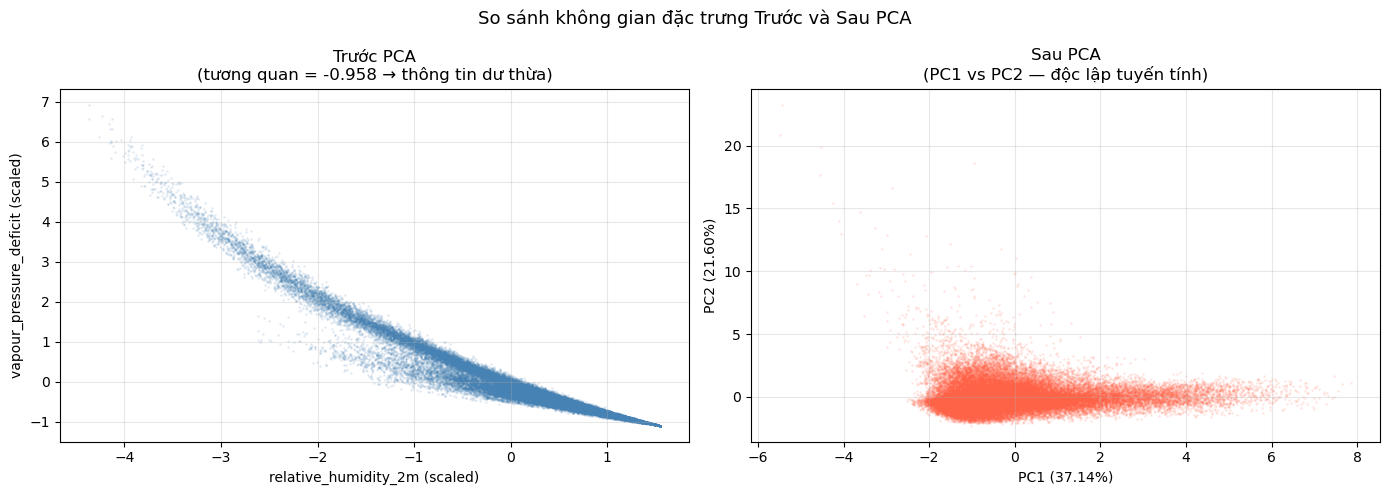

=== SO SÁNH TRƯỚC VÀ SAU PCA ===
Trước PCA: 6 chiều
Sau PCA:   5 chiều
Variance giữ lại: 99.50%
Variance mất đi:  0.50%


In [46]:
# ==================================================
# TRỰC QUAN HÓA: So sánh không gian đặc trưng Trước và Sau PCA
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trước PCA — cặp biến có tương quan cao nhất (-0.958)
axes[0].scatter(X_train_scaled[:, 2], X_train_scaled[:, 5],
                alpha=0.1, s=1, color='steelblue')
axes[0].set_xlabel('relative_humidity_2m (scaled)')
axes[0].set_ylabel('vapour_pressure_deficit (scaled)')
axes[0].set_title('Trước PCA\n(tương quan = -0.958 → thông tin dư thừa)')
axes[0].grid(True, alpha=0.3)

# Sau PCA — PC1 vs PC2 độc lập tuyến tính
axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                alpha=0.1, s=1, color='tomato')
axes[1].set_xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)')
axes[1].set_title('Sau PCA\n(PC1 vs PC2 — độc lập tuyến tính)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh không gian đặc trưng Trước và Sau PCA', fontsize=13)
plt.tight_layout()
plt.show()

print("=== SO SÁNH TRƯỚC VÀ SAU PCA ===")
print(f"Trước PCA: {X_train_scaled.shape[1]} chiều")
print(f"Sau PCA:   {X_train_pca.shape[1]} chiều")
print(f"Variance giữ lại: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Variance mất đi:  {(1-pca_final.explained_variance_ratio_.sum())*100:.2f}%")

---
## 3. Trích xuất đặc trưng thời gian (Sin/Cos Encoding)

Dựa trên kết quả phân tích EDA (seasonal decompose và ACF/PACF), dữ liệu nhiệt độ Đà Nẵng có **2 chu kỳ rõ ràng**:
- **Chu kỳ ngày (24 giờ)**: nhiệt độ thấp nhất ~5-6h sáng, cao nhất ~12-13h trưa
- **Chu kỳ năm (12 tháng)**: mùa hè nóng (tháng 6-8), mùa đông mát (tháng 12-1)

Sử dụng biến đổi sin/cos để mã hóa tính tuần hoàn, đảm bảo giờ 23 và giờ 0 được nhận diện là gần nhau.

=== TIME ENCODING: GIỜ TRONG NGÀY ===
                  time  hour      sin_hour      cos_hour
0  2021-01-01 00:00:00     0  0.000000e+00  1.000000e+00
1  2021-01-01 01:00:00     1  2.588190e-01  9.659258e-01
2  2021-01-01 02:00:00     2  5.000000e-01  8.660254e-01
3  2021-01-01 03:00:00     3  7.071068e-01  7.071068e-01
4  2021-01-01 04:00:00     4  8.660254e-01  5.000000e-01
5  2021-01-01 05:00:00     5  9.659258e-01  2.588190e-01
6  2021-01-01 06:00:00     6  1.000000e+00  6.123234e-17
7  2021-01-01 07:00:00     7  9.659258e-01 -2.588190e-01
8  2021-01-01 08:00:00     8  8.660254e-01 -5.000000e-01
9  2021-01-01 09:00:00     9  7.071068e-01 -7.071068e-01
10 2021-01-01 10:00:00    10  5.000000e-01 -8.660254e-01
11 2021-01-01 11:00:00    11  2.588190e-01 -9.659258e-01
12 2021-01-01 12:00:00    12  1.224647e-16 -1.000000e+00
13 2021-01-01 13:00:00    13 -2.588190e-01 -9.659258e-01
14 2021-01-01 14:00:00    14 -5.000000e-01 -8.660254e-01
15 2021-01-01 15:00:00    15 -7.071068e-01 -7.0710

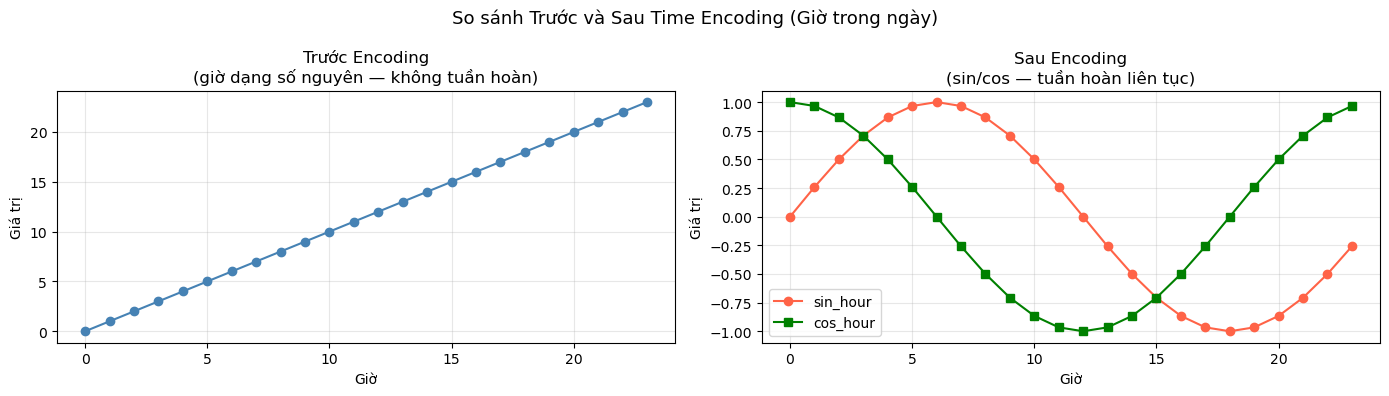

In [47]:
# ==================================================
# 3.1 Sin/Cos encoding cho giờ trong ngày (chu kỳ 24h)
# Dựa trên kết quả EDA: dữ liệu có chu kỳ ngày rõ ràng
# ==================================================

# Tạo trên train
train_df['hour']     = train_df['time'].dt.hour
train_df['sin_hour'] = np.sin(2 * np.pi * train_df['hour'] / 24)
train_df['cos_hour'] = np.cos(2 * np.pi * train_df['hour'] / 24)

# Tạo trên test
test_df['hour']     = test_df['time'].dt.hour
test_df['sin_hour'] = np.sin(2 * np.pi * test_df['hour'] / 24)
test_df['cos_hour'] = np.cos(2 * np.pi * test_df['hour'] / 24)

print("=== TIME ENCODING: GIỜ TRONG NGÀY ===")
print(train_df[['time', 'hour', 'sin_hour', 'cos_hour']].head(24).to_string())

# Trực quan hóa trước và sau encoding giờ
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hours = range(24)
axes[0].plot(hours, list(hours), marker='o', color='steelblue')
axes[0].set_title('Trước Encoding\n(giờ dạng số nguyên — không tuần hoàn)')
axes[0].set_xlabel('Giờ')
axes[0].set_ylabel('Giá trị')
axes[0].grid(True, alpha=0.3)

sin_vals = np.sin(2 * np.pi * np.array(list(hours)) / 24)
cos_vals = np.cos(2 * np.pi * np.array(list(hours)) / 24)
axes[1].plot(hours, sin_vals, marker='o', color='tomato',  label='sin_hour')
axes[1].plot(hours, cos_vals, marker='s', color='green',   label='cos_hour')
axes[1].set_title('Sau Encoding\n(sin/cos — tuần hoàn liên tục)')
axes[1].set_xlabel('Giờ')
axes[1].set_ylabel('Giá trị')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh Trước và Sau Time Encoding (Giờ trong ngày)', fontsize=13)
plt.tight_layout()
plt.show()

=== TIME ENCODING: THÁNG TRONG NĂM ===
       month     sin_month     cos_month
month                                   
1          1  5.000000e-01  8.660254e-01
2          2  8.660254e-01  5.000000e-01
3          3  1.000000e+00  6.123234e-17
4          4  8.660254e-01 -5.000000e-01
5          5  5.000000e-01 -8.660254e-01
6          6  1.224647e-16 -1.000000e+00
7          7 -5.000000e-01 -8.660254e-01
8          8 -8.660254e-01 -5.000000e-01
9          9 -1.000000e+00 -1.836970e-16
10        10 -8.660254e-01  5.000000e-01
11        11 -5.000000e-01  8.660254e-01
12        12 -2.449294e-16  1.000000e+00


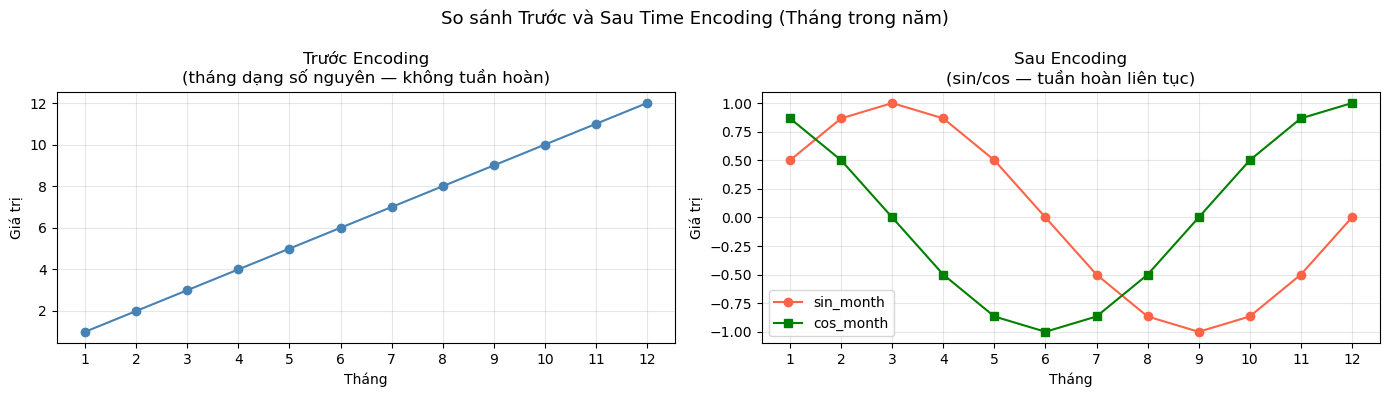

In [48]:
# ==================================================
# 3.2 Sin/Cos encoding cho tháng trong năm (chu kỳ 12 tháng)
# Dựa trên kết quả EDA: seasonal decompose cho thấy chu kỳ năm rõ ràng
# ==================================================

# Tạo trên train
train_df['month']     = train_df['time'].dt.month
train_df['sin_month'] = np.sin(2 * np.pi * train_df['month'] / 12)
train_df['cos_month'] = np.cos(2 * np.pi * train_df['month'] / 12)

# Tạo trên test
test_df['month']     = test_df['time'].dt.month
test_df['sin_month'] = np.sin(2 * np.pi * test_df['month'] / 12)
test_df['cos_month'] = np.cos(2 * np.pi * test_df['month'] / 12)

print("=== TIME ENCODING: THÁNG TRONG NĂM ===")
monthly_sample = train_df.groupby('month')[['month', 'sin_month', 'cos_month']].first()
print(monthly_sample.to_string())

# Trực quan hóa trước và sau encoding tháng
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

months = range(1, 13)
axes[0].plot(months, list(months), marker='o', color='steelblue')
axes[0].set_title('Trước Encoding\n(tháng dạng số nguyên — không tuần hoàn)')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Giá trị')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

sin_m = np.sin(2 * np.pi * np.array(list(months)) / 12)
cos_m = np.cos(2 * np.pi * np.array(list(months)) / 12)
axes[1].plot(months, sin_m, marker='o', color='tomato', label='sin_month')
axes[1].plot(months, cos_m, marker='s', color='green',  label='cos_month')
axes[1].set_title('Sau Encoding\n(sin/cos — tuần hoàn liên tục)')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Giá trị')
axes[1].set_xticks(range(1, 13))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh Trước và Sau Time Encoding (Tháng trong năm)', fontsize=13)
plt.tight_layout()
plt.show()

In [49]:
# ==================================================
# Thêm encoding vào train_pca_df và test_pca_df
# ==================================================
train_pca_df['sin_hour']  = train_df['sin_hour'].values
train_pca_df['cos_hour']  = train_df['cos_hour'].values
train_pca_df['sin_month'] = train_df['sin_month'].values
train_pca_df['cos_month'] = train_df['cos_month'].values

test_pca_df['sin_hour']  = test_df['sin_hour'].values
test_pca_df['cos_hour']  = test_df['cos_hour'].values
test_pca_df['sin_month'] = test_df['sin_month'].values
test_pca_df['cos_month'] = test_df['cos_month'].values

print("Sau khi thêm Time Encoding vào PCA DataFrame:")
print(f"Train columns: {train_pca_df.columns.tolist()}")

Sau khi thêm Time Encoding vào PCA DataFrame:
Train columns: ['time', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'temperature_2m', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month']


---
## 4. Tạo đặc trưng trễ (Lag Features)

Dựa trên phân tích ACF/PACF và Lag Plots từ EDA, nhiệt độ có tính tự tương quan cao theo thời gian. Các lag features được chọn dựa trên ý nghĩa vật lý:
- **lag_1, lag_2, lag_3**: Quán tính nhiệt ngắn hạn
- **lag_12**: Nghịch đảo bức xạ ngày/đêm (12h trước)
- **lag_24**: Cùng khung giờ hôm qua (chu kỳ ngày)
- **lag_72**: 3 ngày trước (xu hướng ngắn hạn)
- **lag_168**: 1 tuần trước (chu kỳ tuần)

In [50]:
# ==================================================
# 4. Tạo Lag Features
# Ghép train + test trước khi tạo lag để test có đủ giá trị lịch sử
# ==================================================

# Đánh dấu is_train để tách lại sau
train_pca_df['is_train'] = 1
test_pca_df['is_train']  = 0

# Ghép lại và sắp xếp theo thời gian
full_df = pd.concat([train_pca_df, test_pca_df], ignore_index=True)
full_df = full_df.sort_values('time').reset_index(drop=True)

# Tạo lag features
lag_hours = [1, 2, 3, 12, 24, 72, 168]
for lag in lag_hours:
    full_df[f'temp_lag_{lag}'] = full_df['temperature_2m'].shift(lag)

# Tách lại train và test, dropna loại bỏ các dòng không đủ lịch sử
train_final = full_df[full_df['is_train'] == 1].dropna().reset_index(drop=True)
test_final  = full_df[full_df['is_train'] == 0].dropna().reset_index(drop=True)

# Bỏ cột is_train
train_final = train_final.drop(columns=['is_train'])
test_final  = test_final.drop(columns=['is_train'])

print("=== KẾT QUẢ LAG FEATURES ===")
print(f"\nTrain shape: {train_final.shape}")
print(f"Test shape:  {test_final.shape}")
print(f"\nCác cột lag: {[col for col in train_final.columns if 'lag' in col]}")
print(f"\nTất cả cột: {train_final.columns.tolist()}")
print(f"\nTrain time range: {train_final['time'].min()} → {train_final['time'].max()}")
print(f"Test time range:  {test_final['time'].min()} → {test_final['time'].max()}")

=== KẾT QUẢ LAG FEATURES ===

Train shape: (42405, 18)
Test shape:  (4731, 18)

Các cột lag: ['temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_12', 'temp_lag_24', 'temp_lag_72', 'temp_lag_168']

Tất cả cột: ['time', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'temperature_2m', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_12', 'temp_lag_24', 'temp_lag_72', 'temp_lag_168']

Train time range: 2021-01-08 00:00:00 → 2025-11-09 20:00:00
Test time range:  2025-11-09 21:00:00 → 2026-05-25 23:00:00


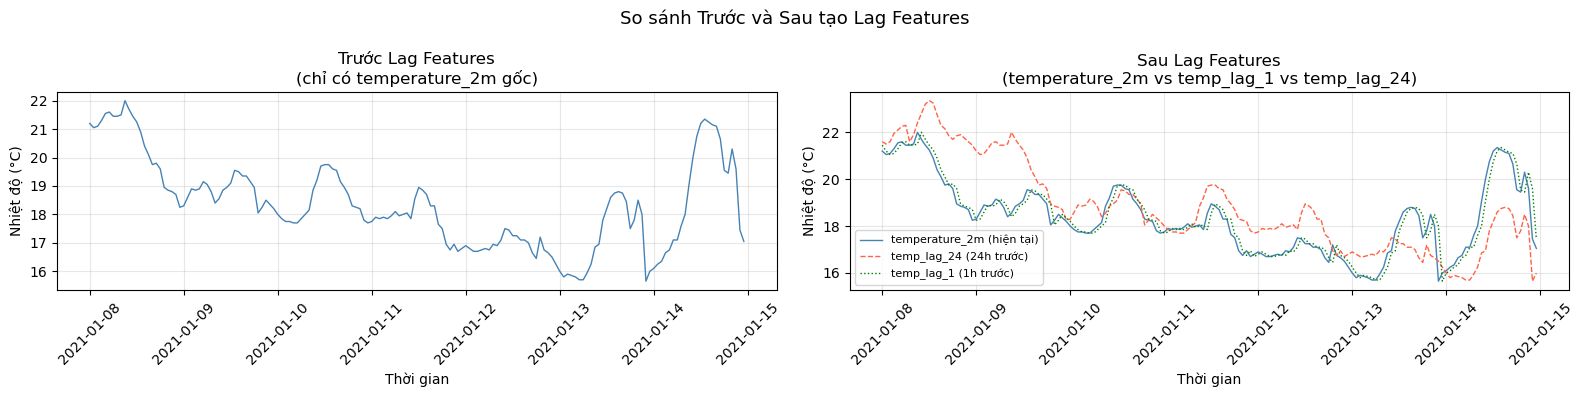

In [51]:
# ==================================================
# TRỰC QUAN HÓA: So sánh Trước và Sau tạo Lag Features
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Lấy 7 ngày đầu để visualize rõ
sample = train_final.iloc[:168]

# Trước lag — chỉ có temperature_2m gốc
axes[0].plot(sample['time'], sample['temperature_2m'],
             color='steelblue', linewidth=1)
axes[0].set_title('Trước Lag Features\n(chỉ có temperature_2m gốc)')
axes[0].set_xlabel('Thời gian')
axes[0].set_ylabel('Nhiệt độ (°C)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Sau lag — so sánh temp và lag_24
axes[1].plot(sample['time'], sample['temperature_2m'],
             color='steelblue', linewidth=1, label='temperature_2m (hiện tại)')
axes[1].plot(sample['time'], sample['temp_lag_24'],
             color='tomato', linewidth=1, linestyle='--', label='temp_lag_24 (24h trước)')
axes[1].plot(sample['time'], sample['temp_lag_1'],
             color='green', linewidth=1, linestyle=':', label='temp_lag_1 (1h trước)')
axes[1].set_title('Sau Lag Features\n(temperature_2m vs temp_lag_1 vs temp_lag_24)')
axes[1].set_xlabel('Thời gian')
axes[1].set_ylabel('Nhiệt độ (°C)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh Trước và Sau tạo Lag Features', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Tổng hợp bộ đặc trưng cuối cùng

In [52]:
# ==================================================
# 5. Tổng hợp và thống kê bộ đặc trưng cuối cùng
# ==================================================
feature_cols_final = [col for col in train_final.columns
                      if col not in ['time', 'temperature_2m']]

print("=" * 55)
print("TỔNG HỢP BỘ ĐẶC TRƯNG CUỐI CÙNG")
print("=" * 55)
print(f"\nBiến mục tiêu: temperature_2m")
print(f"\nCác features đầu vào ({len(feature_cols_final)} biến):")
for i, col in enumerate(feature_cols_final, 1):
    print(f"  {i:2d}. {col}")

print(f"\n{'Tập dữ liệu':<15} {'Số mẫu':>10} {'Số features':>12} {'Khoảng thời gian'}")
print("-" * 70)
print(f"{'Train':<15} {len(train_final):>10} {len(feature_cols_final):>12} "
      f"{train_final['time'].min().date()} → {train_final['time'].max().date()}")
print(f"{'Test':<15} {len(test_final):>10} {len(feature_cols_final):>12} "
      f"{test_final['time'].min().date()} → {test_final['time'].max().date()}")

print("\n5 dòng đầu Train:")
print(train_final.head())

TỔNG HỢP BỘ ĐẶC TRƯNG CUỐI CÙNG

Biến mục tiêu: temperature_2m

Các features đầu vào (16 biến):
   1. PC1
   2. PC2
   3. PC3
   4. PC4
   5. PC5
   6. sin_hour
   7. cos_hour
   8. sin_month
   9. cos_month
  10. temp_lag_1
  11. temp_lag_2
  12. temp_lag_3
  13. temp_lag_12
  14. temp_lag_24
  15. temp_lag_72
  16. temp_lag_168

Tập dữ liệu         Số mẫu  Số features Khoảng thời gian
----------------------------------------------------------------------
Train                42405           16 2021-01-08 → 2025-11-09
Test                  4731           16 2025-11-09 → 2026-05-25

5 dòng đầu Train:
                 time       PC1       PC2       PC3       PC4       PC5  \
0 2021-01-08 00:00:00 -1.323048  0.419816 -0.073624  0.794602 -0.336020   
1 2021-01-08 01:00:00 -1.362823  0.653598 -0.126276  0.706323 -0.116376   
2 2021-01-08 02:00:00 -1.636249  1.015001  0.325073  0.095126 -0.464291   
3 2021-01-08 03:00:00 -1.492724  1.122267  0.100413  0.241169 -0.077741   
4 2021-01-08 04:0

In [53]:
# =======================================================
# CHUẨN BỊ 3 PHIÊN BẢN DATASET TỪ CÁC BIẾN ĐÃ CÓ
# =======================================================
# feature_cols là 6 cột thống kê được chuẩn hóa ở phần PCA
feature_cols_stats = ['wind_speed_10m', 'cloud_cover', 'relative_humidity_2m',
                      'surface_pressure', 'precipitation', 'vapour_pressure_deficit']

# 1. Dataset FE_PCA (Chính là tập từ PCA)
X_train_fe_pca = train_final[[col for col in train_final.columns 
                               if col not in ['time', 'temperature_2m']]].copy()
y_train_fe_pca = train_final['temperature_2m'].copy()
X_test_fe_pca = test_final[[col for col in test_final.columns 
                             if col not in ['time', 'temperature_2m']]].copy()
y_test_fe_pca = test_final['temperature_2m'].copy()

# 2. Dataset RAW (Không qua chuẩn hóa, không Lag/Time)
# Lấy các dòng tương ứng với index của train_final để đảm bảo cùng số lượng mẫu (sau khi đã drop NA do Lag)
X_train_raw = train_df.loc[train_final.index, feature_cols_stats].reset_index(drop=True)
y_train_raw = train_df.loc[train_final.index, 'temperature_2m'].reset_index(drop=True)
X_test_raw = test_df.loc[test_final.index, feature_cols_stats].reset_index(drop=True)
y_test_raw = test_df.loc[test_final.index, 'temperature_2m'].reset_index(drop=True)

# 3. Dataset FE_no_PCA (Có Chuẩn hóa + Lag/Time, nhưng KHÔNG dùng PCA)
# Lấy các cột Lag và Time (các cột không có chữ 'PC' trong tên)
time_lag_cols = [c for c in X_train_fe_pca.columns if not str(c).startswith('PC')]

# Đưa array X_train_scaled về DataFrame với đúng 6 cột
X_train_scaled_df = pd.DataFrame(X_train_scaled, 
                                 columns=feature_cols_stats, 
                                 index=train_df.index).loc[train_final.index].reset_index(drop=True)
X_test_scaled_df = pd.DataFrame(X_test_scaled, 
                                columns=feature_cols_stats, 
                                index=test_df.index).loc[test_final.index].reset_index(drop=True)

# Lấy các cột lag + time từ X_train_fe_pca và ghép với scaled data
X_train_lag_time = X_train_fe_pca[time_lag_cols].reset_index(drop=True)
X_test_lag_time = X_test_fe_pca[time_lag_cols].reset_index(drop=True)

X_train_fe_no_pca = pd.concat([X_train_scaled_df, X_train_lag_time], axis=1)
X_test_fe_no_pca = pd.concat([X_test_scaled_df, X_test_lag_time], axis=1)

print("Đã tạo thành công 3 phiên bản dữ liệu:")
print(f"   • Raw: {X_train_raw.shape} (chỉ 6 cột thống kê gốc)")
print(f"   • FE_no_PCA: {X_train_fe_no_pca.shape} (chuẩn hóa + lag/time)")
print(f"   • FE_PCA: {X_train_fe_pca.shape} (PCA + lag/time)")
print(f"\n   y_train_raw: {y_train_raw.shape}")
print(f"   y_train_fe_pca: {y_train_fe_pca.shape}")

Đã tạo thành công 3 phiên bản dữ liệu:
   • Raw: (42405, 6) (chỉ 6 cột thống kê gốc)
   • FE_no_PCA: (42405, 17) (chuẩn hóa + lag/time)
   • FE_PCA: (42405, 16) (PCA + lag/time)

   y_train_raw: (42405,)
   y_train_fe_pca: (42405,)


# PHẦN 5: HUẤN LUYỆN MÔ HÌNH THỐNG KÊ & MACHINE LEARNING

## 5.1. Mô hình SARIMAX (Thống kê)
Vì SARIMAX đào tạo trên số lượng dữ liệu lớn tốn rất nhiều thời gian, ta sẽ sử dụng biến ngoại sinh (exog) và chạy so sánh giữa `Raw` và `FE_no_PCA` (Mô hình thống kê thường kén PCA vì mất đi ý nghĩa diễn giải vật lý).

In [54]:
# =======================================================
# TỰ ĐỘNG DÒ TÌM THAM SỐ (AUTO-ARIMA) VÀ HUẤN LUYỆN SARIMAX
# =======================================================
# Nếu máy chưa cài thư viện pmdarima, hãy bỏ comment dòng dưới đây để cài đặt:
# !pip install pmdarima

import pmdarima as pm
import statsmodels.api as sm

print("Đang tự động dò tìm bộ tham số (p, d, q) tối ưu nhất...\n")

y_search = y_train_raw
X_search = X_train_raw

# 1. Chạy Auto-ARIMA để tìm tham số
auto_model = pm.auto_arima(
    y=y_search,
    X=X_search,
    start_p=0, start_q=0,
    max_p=3, max_q=3,     # Giới hạn tìm kiếm tối đa bậc 3
    d=0,                  # Do test ADF, đã khẳng định dữ liệu đã stationarized, nên d=0
    seasonal=False,       # Tắt seasonal của ARIMA vì nhóm đã dùng Sin/Cos encoding thay thế
    trace=True,           # Bật True để in ra log quá trình máy đang thử nghiệm
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True         # Dùng thuật toán tìm kiếm thông minh (nhanh hơn vét cạn Grid Search)
)

best_order = auto_model.order
print(f"\n=> TÌM KIẾM HOÀN TẤT! Bộ tham số tốt nhất là: order={best_order}")
print("-" * 60)

# 2. Lấy bộ tham số vừa tìm được để huấn luyện mô hình chính thức
# 2.1. Huấn luyện và lưu mô hình RAW
print(f"Đang huấn luyện SARIMAX {best_order} trên dữ liệu (RAW)...")
model_sarima_raw = sm.tsa.SARIMAX(endog=y_train_raw, exog=X_train_raw, order=best_order)
res_sarima_raw = model_sarima_raw.fit(disp=False)
res_sarima_raw.save('sarimax_raw_model.pkl') # <--- Lưu mô hình RAW

# 2.2. Huấn luyện và lưu mô hình FE no PCA
print(f"Đang huấn luyện SARIMAX {best_order} trên dữ liệu (FE no PCA)...")
model_sarima_fe = sm.tsa.SARIMAX(endog=y_train_raw, exog=X_train_fe_no_pca, order=best_order)
res_sarima_fe = model_sarima_fe.fit(disp=False)
res_sarima_fe.save('sarimax_fe_model.pkl') # <--- Lưu mô hình FE no PCA

# 2.3. Huấn luyện và lưu mô hình FE có PCA
print(f"Đang huấn luyện SARIMAX {best_order} trên dữ liệu (FE CÓ PCA)...")
model_sarima_pca = sm.tsa.SARIMAX(endog=y_train_fe_pca, exog=X_train_fe_pca, order=best_order)
res_sarima_pca = model_sarima_pca.fit(disp=False)
res_sarima_pca.save('sarimax_pca_model.pkl') # <--- Lưu mô hình FE CÓ PCA

print("Đã huấn luyện và lưu thành công cả 3 mô hình SARIMAX!")

Đang tự động dò tìm bộ tham số (p, d, q) tối ưu nhất...

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=181330.672, Time=63.39 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=19605.817, Time=40.46 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=133423.394, Time=52.80 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=43378.072, Time=55.29 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=57591.124, Time=55.69 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=27182.429, Time=60.13 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=21089.545, Time=45.44 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 373.205 seconds

=> TÌM KIẾM HOÀN TẤT! Bộ tham số tốt nhất là: order=(1, 0, 0)
------------------------------------------------------------
Đang huấn luyện SARIMAX (1, 0, 0) trên dữ liệu (RAW)...


d:\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Đang huấn luyện SARIMAX (1, 0, 0) trên dữ liệu (FE no PCA)...
Đang huấn luyện SARIMAX (1, 0, 0) trên dữ liệu (FE CÓ PCA)...


d:\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Đã huấn luyện và lưu thành công cả 3 mô hình SARIMAX!


In [55]:
print("="*50)
print("BƯỚC 4: TÁCH BIẾN NGOẠI SINH (FEATURES) VÀ BIẾN MỤC TIÊU (TARGET)")
print("="*50)

# Định nghĩa danh sách các đặc trưng (bao gồm biến trễ và biến ngoại sinh)
# Nếu dữ liệu của bạn có thêm cột 'relative_humidity_2m (%)' hoặc 'rain', hãy thêm vào list này nhé!
feature_cols = [
    'hour', 'day_of_week', 'day_of_month', 'month', 'day_of_year',
    'lag_1', 'lag_2', 'lag_3', 'lag_24',
    'rolling_mean_24', 'rolling_std_24'
]

target_col = 'temperature_2m (°C)'

# Tách thành ma trận X và mảng y
X_train = train_df[feature_cols]
y_train = train_df[target_col]

print(f"✅ Đã cấu hình xong không gian đặc trưng (Feature Space):")
print(f" - Số lượng biến ngoại sinh và biến trễ đầu vào (X): {len(feature_cols)} biến.")
print(f" - Biến mục tiêu cần dự báo (y): '{target_col}'")
print(f" - Kích thước X_train: {X_train.shape}")
print(f" - Kích thước y_train: {y_train.shape}")

BƯỚC 4: TÁCH BIẾN NGOẠI SINH (FEATURES) VÀ BIẾN MỤC TIÊU (TARGET)


KeyError: "['day_of_week', 'day_of_month', 'day_of_year', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'rolling_mean_24', 'rolling_std_24'] not in index"

In [ ]:
import xgboost as xgb
import pickle
import os

print("="*50)
print("BƯỚC 5: HUẤN LUYỆN MÔ HÌNH XGBOOST REGRESSOR")
print("="*50)

# 1. KHỞI TẠO MÔ HÌNH XGBOOST
# Cấu hình các tham số để kiểm soát overfitting và tối ưu cho chuỗi thời gian
model = xgb.XGBRegressor(
    n_estimators=100,      # Số lượng cây quyết định
    max_depth=6,           # Độ sâu tối đa của cây
    learning_rate=0.1,     # Tốc độ học
    subsample=0.8,         # Tỷ lệ lấy mẫu dòng cho mỗi cây (chống overfitting)
    colsample_bytree=0.8,  # Tỷ lệ lấy mẫu cột (biến ngoại sinh) cho mỗi cây
    random_state=42,
    n_jobs=-1              # Sử dụng tối đa hiệu năng CPU để train nhanh
)

# 2. TIẾN HÀNH HUẤN LUYỆN (FIT MODEL)
print("-> Đang huấn luyện mô hình XGBoost với các biến ngoại sinh...")
model.fit(X_train, y_train)
print("✅ Huấn luyện mô hình thành công!")

# 3. ĐÓNG GÓI VÀ LƯU TRỮ MÔ HÌNH (ĐỂ DÙNG BÊN FILE TESTING.IPYNB)
# Tạo thư mục lưu trữ nếu chưa có
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)

# Lưu model XGBoost
model_path = os.path.join(model_dir, "xgboost_weather_model.pkl")
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

# Lưu kèm danh sách cột thuộc tính để bên test_df trích xuất khớp 100%
features_path = os.path.join(model_dir, "feature_columns.pkl")
with open(features_path, 'wb') as f:
    pickle.dump(feature_cols, f)

print(f"\n📦 Đã đóng gói và lưu trữ thành công:")
print(f" - File mô hình: {model_path}")
print(f" - File danh sách đặc trưng: {features_path}")